In [1]:
import os
import math
import pickle
import sys

import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
matplotlib.rcParams['text.usetex'] = False
import numpy as np
import pandas as pd
from tqdm import tqdm

sys.path.insert(0, '..')
from plot_config import MODEL_COLORS, MODEL_DISPLAY_NAMES, MODEL_MARKERS, FONT_SIZES

plt.rcParams.update(FONT_SIZES)

In [2]:
project_root = "../../../.."

#Set error rate level for this analysis
error_rate_level = "typical" # toggle here; "typical", "high", "stress"

# Minimum IoU threshold for a predicted CDS to be considered a true positive match
overlap_criteria = 0.8 # 0.5 and 0.8 tested for each analysis in addition to 1; placed in supplementary 

#Load data if already processed; set to False to re-run data processing and overwrite cached results
LOAD_PROCESSED_DATA = True

In [3]:
if error_rate_level == "typical":
    indel_rate = "5e-06"
    sub_rate = "0.004"
elif error_rate_level == "high":
    indel_rate = "1.25e-05"
    sub_rate = "0.01"
elif error_rate_level == "stress":
    indel_rate = "3.75e-05"
    sub_rate = "0.03"
else:
    raise ValueError(f"Invalid error_rate_level: {error_rate_level}. Must be one of 'typical', 'high', 'stress'")

all_test_accessions = open(f"{project_root}/data/processed_data/genome_partitions/test_partition_accessions.txt").read().splitlines()

# Load genome info from CSV and create dict for all test accessions
genome_info_df = pd.read_csv(f"{project_root}/data/processed_data/dataset_information/genomes_info_with_partitions.csv")
genome_info_df = genome_info_df.set_index('accession')

# Families that use translation table 4 (Mycoplasmataceae and related)
tt4_families = ['Mycoplasmataceae']

all_genomes = {}
for acc in all_test_accessions:
    if acc in genome_info_df.index:
        row = genome_info_df.loc[acc]
        translation_table = 4 if row['family'] in tt4_families else 11
        all_genomes[acc] = {
            'family': row['family'],
            'domain': row['domain'],
            'gc_content': row['gc_content'],
            'translation_table': translation_table
        }

print(f"Total test accessions: {len(all_test_accessions)}")
print(f"Error rates: indel={indel_rate}, substitution={sub_rate}")

# Human-readable error rate label for plot titles
indel_pct = float(indel_rate) * 2 * 100
sub_pct = float(sub_rate) * 100
error_rate_label = f"indel rate={indel_pct}%, substitution rate={sub_pct}%"

model_names = ["fgs_complete", "fgs_illumina_5", "fgs_illumina_10", "prodigal",
               "deep_cds_no_errors",
               "deep_cds_substitution", "deep_cds_errors"]

read_lengths = [75, 100, 150, 300]
models_per_length = {length: model_names for length in read_lengths}

_script_name = "cds_level_read_length_disrupted_rf_aware"

# Cache path encodes current settings — each combination of error rates and overlap_criteria
# gets its own subdirectory.
_cache_dir = (
    f"{project_root}/data/processed_data/report_results/with_errors/{_script_name}"
    f"/{indel_rate}i_{sub_rate}s"
    f"/30bp_False_oc_{overlap_criteria}"
)

Total test accessions: 215
Error rates: indel=5e-06, substitution=0.004


In [4]:
def get_full_cds(reads_dict):
    """Merge fragmented CDS annotations that belong to the same gene.

    When a CDS is split into multiple fragments (e.g. due to short fragment
    removal during preprocessing), this function reconnects them into a single
    CDS span using the cds_fragments_connection mapping. The merged CDS is
    labelled 'disrupted_rf' and replaces the individual fragments.

    The original per-fragment coordinates (each with its own RF label) are
    preserved as a 4th element so that calculate_iou can determine which
    positions within the disrupted span belong to which reading frame:
        [start, end, 'disrupted_rf', [(s1, e1, rf1), (s2, e2, rf2), ...]]

    Args:
        reads_dict: Dict mapping read names to dicts with 'cds_coords' (list of
            [start, end, rf] triplets) and 'cds_fragments_connection' (list of
            index groups indicating which fragments belong together).

    Returns:
        The modified reads_dict with fragmented CDS entries merged.
    """
    for read in reads_dict.keys():
        cds_fragments_connections = reads_dict[read]['cds_fragments_connection']
        cds_coords = reads_dict[read]['cds_coords']

        indices_to_remove = []
        
        for cds_frag_mapping in cds_fragments_connections:
            if len(cds_frag_mapping) > 1:
                # Postprocessing for testset due to how short fragments were removed
                if len(cds_fragments_connections) != cds_frag_mapping[0] + 1:
                    if len(cds_frag_mapping) == 1:
                        cds_frag_mapping = [cds_index - 1 for cds_index in cds_frag_mapping]
                
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [0, 2]:
                    cds_frag_mapping = [0, 1]
                elif len(cds_fragments_connections) == 1 and cds_frag_mapping == [2, 3, 4]:
                    cds_frag_mapping = [0, 1, 2]
                
                start_cds_frag = cds_coords[min(cds_frag_mapping)][0]
                end_cds_frag = cds_coords[max(cds_frag_mapping)][1]

                # Preserve individual fragment coordinates sorted by start position.
                fragment_list = sorted(
                    [(cds_coords[i][0], cds_coords[i][1], cds_coords[i][2])
                     for i in cds_frag_mapping],
                    key=lambda f: f[0]
                )

                indices_to_remove += cds_frag_mapping
                
                assert start_cds_frag < end_cds_frag, "Something went wrong processing indel-induced error in sequence!"
                cds_coords.append([start_cds_frag, end_cds_frag, 'disrupted_rf', fragment_list])
                reads_dict[read]['cds_coords'] = cds_coords

        for index in sorted(indices_to_remove, reverse=True):
            cds_coords.pop(index)
    
    return reads_dict


def _get_rf_spans(coord):
    """Extract per-RF coordinate spans from a CDS coord entry.

    Args:
        coord: [start, end, rf] or [start, end, 'disrupted_rf', [(s,e,rf), ...]].

    Returns:
        Dict mapping rf_label -> list of (start, end) tuples.
    """
    if len(coord) == 4 and coord[2] == 'disrupted_rf':
        by_rf = {}
        for s, e, rf in coord[3]:
            by_rf.setdefault(rf, []).append((s, e))
        return by_rf
    else:
        return {coord[2]: [(coord[0], coord[1])]}


def _overlap(s1, e1, s2, e2):
    return max(0, min(e1, e2) - max(s1, s2))


def _total_span_length(spans_by_rf):
    return sum(e - s for spans in spans_by_rf.values() for s, e in spans)


def _rf_intersection(spans_a, spans_b):
    """Total coordinate overlap between two lists of (start, end) spans (same RF)."""
    total = 0
    for s1, e1 in spans_a:
        for s2, e2 in spans_b:
            total += _overlap(s1, e1, s2, e2)
    return total


def calculate_iou(coord1, coord2):
    """Calculate IoU between two CDS entries, disrupted-RF-aware.

    coord1 is the prediction; coord2 is the truth.  Handles five cases:

    1. Both single-RF, same RF: standard coordinate IoU.
    2. Both single-RF, different RF: returns 0.0.
    3. Pred=single-RF, truth=disrupted_rf:
       IoU = intersection(pred, truth's matching-RF sub-span)
             / union(pred, truth's matching-RF sub-span).
       Truth's non-matching RF sub-spans are NOT counted as FN — the prediction
       only claims to have found one RF of the gene.
    4. Pred=disrupted_rf, truth=single-RF:
       TP = intersection(pred's matching-RF sub-span, truth).
       All non-matching RF sub-spans of pred count as FP (model predicted an
       indel that is absent in the truth).
       IoU = TP / (|pred_total| + |truth| - TP).
    5. Both disrupted_rf:
       RF-by-RF fragment comparison merged into one IoU:
       IoU = sum(intersection_rf) / (|pred_total| + |truth_total| - sum(intersection_rf)).

    Args:
        coord1: Prediction — [start, end, rf] or
                [start, end, 'disrupted_rf', [(s, e, rf), ...]].
        coord2: Truth — same format as coord1.

    Returns:
        IoU value in [0.0, 1.0].
    """
    pred_disrupted = coord1[2] == 'disrupted_rf'
    truth_disrupted = coord2[2] == 'disrupted_rf'

    # Cases 1 & 2: both single-RF
    if not pred_disrupted and not truth_disrupted:
        if coord1[2] != coord2[2]:
            return 0.0
        inter = _overlap(coord1[0], coord1[1], coord2[0], coord2[1])
        if inter == 0:
            return 0.0
        union = (coord1[1] - coord1[0]) + (coord2[1] - coord2[0]) - inter
        return inter / union if union > 0 else 0.0

    pred_spans = _get_rf_spans(coord1)
    truth_spans = _get_rf_spans(coord2)

    # Case 3: pred=single-RF, truth=disrupted_rf
    # Evaluate pred only against the matching-RF sub-span of the truth.
    if not pred_disrupted and truth_disrupted:
        rf = coord1[2]
        if rf not in truth_spans:
            return 0.0
        pred_len = coord1[1] - coord1[0]
        truth_rf_len = sum(e - s for s, e in truth_spans[rf])
        inter = _rf_intersection([(coord1[0], coord1[1])], truth_spans[rf])
        denom = pred_len + truth_rf_len - inter
        return inter / denom if denom > 0 else 0.0

    # Case 4: pred=disrupted_rf, truth=single-RF
    # Non-matching RF sub-spans of pred are FP.
    if pred_disrupted and not truth_disrupted:
        rf = coord2[2]
        truth_len = coord2[1] - coord2[0]
        pred_total_len = _total_span_length(pred_spans)
        inter = 0
        if rf in pred_spans:
            inter = _rf_intersection(pred_spans[rf], [(coord2[0], coord2[1])])
        denom = pred_total_len + truth_len - inter
        return inter / denom if denom > 0 else 0.0

    # Case 5: both disrupted_rf — RF-by-RF fragment comparison
    all_rfs = set(pred_spans.keys()) | set(truth_spans.keys())
    pred_total_len = _total_span_length(pred_spans)
    truth_total_len = _total_span_length(truth_spans)
    total_inter = 0
    for rf in all_rfs:
        if rf in pred_spans and rf in truth_spans:
            total_inter += _rf_intersection(pred_spans[rf], truth_spans[rf])
    denom = pred_total_len + truth_total_len - total_inter
    return total_inter / denom if denom > 0 else 0.0


def find_matching_genes(predicted_coords, actual_coords, overlap_criteria):
    """Match predicted CDS to ground-truth CDS using greedy IoU matching.

    Each predicted CDS is matched to the best-overlapping unmatched ground-truth
    CDS, provided the IoU meets the overlap_criteria threshold.

    Args:
        predicted_coords: List of CDS coord entries for predictions.
        actual_coords: List of CDS coord entries for ground-truth.
        overlap_criteria: Minimum IoU threshold for a valid match.

    Returns:
        Tuple of (matched_pairs, num_matches) where matched_pairs is a list of
        (predicted_idx, actual_idx) tuples.
    """
    matched_pairs = []
    used_actual = set()
    used_predicted = set()
    
    for pred_idx, pred_coord in enumerate(predicted_coords):
        best_iou = 0.0
        best_actual_idx = -1
        
        for actual_idx, actual_coord in enumerate(actual_coords):
            if actual_idx in used_actual:
                continue
                
            iou = calculate_iou(pred_coord, actual_coord)
            
            if iou >= overlap_criteria and iou > best_iou:
                best_iou = iou
                best_actual_idx = actual_idx
        
        if best_actual_idx != -1:
            matched_pairs.append((pred_idx, best_actual_idx))
            used_actual.add(best_actual_idx)
            used_predicted.add(pred_idx)
    
    return matched_pairs, len(matched_pairs)


def calculate_metrics(testset_dict, model_preds_dict, all_test_read_names, overlap_criteria):
    """Calculate precision, recall, and F1 score at the CDS level.

    Iterates over all reads, matches predicted CDS to ground-truth CDS using
    IoU-based matching, and aggregates TP/FP/FN counts across all reads.

    Args:
        testset_dict: Dict mapping read names to ground-truth annotations with 'cds_coords'.
        model_preds_dict: Dict mapping read names to model predictions with 'cds_coords'.
        all_test_read_names: List of all read names to evaluate.
        overlap_criteria: Minimum IoU threshold for a match to count as a true positive.

    Returns:
        Dict with keys: overlap_criteria, total_predicted_genes, total_actual_genes,
        total_true_positives, total_false_positives, total_false_negatives,
        precision, recall, f1_score.
    """
    total_tp = 0
    total_predicted_genes = 0
    total_actual_genes = 0
    
    for read_name in all_test_read_names:
        cds_coords_testset = []
        cds_coords_model = []
        
        if read_name in testset_dict:
            cds_coords_testset = testset_dict[read_name].get("cds_coords", [])
        
        if read_name in model_preds_dict:
            cds_coords_model = model_preds_dict[read_name].get("cds_coords", [])
        
        num_predicted = len(cds_coords_model)
        num_actual = len(cds_coords_testset)

        _, tp_count = find_matching_genes(cds_coords_model, cds_coords_testset, overlap_criteria)

        total_predicted_genes += num_predicted
        total_actual_genes += num_actual
        total_tp += tp_count
    
    total_fp = total_predicted_genes - total_tp
    total_fn = total_actual_genes - total_tp
    
    precision = total_tp / total_predicted_genes if total_predicted_genes > 0 else 0.0
    recall = total_tp / total_actual_genes if total_actual_genes > 0 else 0.0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    results = {
        'overlap_criteria': overlap_criteria,
        'total_predicted_genes': total_predicted_genes,
        'total_actual_genes': total_actual_genes,
        'total_true_positives': total_tp,
        'total_false_positives': total_fp,
        'total_false_negatives': total_fn,
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'f1_score': round(f1_score, 3)
    }
    
    return results


In [5]:
def load_testset(test_accession, data_type, project_root=project_root):
    """Load ground-truth testset dict and read names for a genome accession.

    Args:
        test_accession: Genome accession ID (e.g. 'GCF_000011125.1').
        data_type: Dataset identifier (e.g. 'with_errors_3.75e-05i_0.03s_300bp').
        project_root: Path to project root directory.

    Returns:
        Tuple of (read_names_list, testset_dict) where testset_dict has
        fragmented CDS merged via get_full_cds().
    """
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/testset_dict.pkl", "rb") as f:
        testset_dict = pickle.load(f)
    with open(f"{project_root}/data/processed_data/testset_processed/{data_type}/{test_accession}/read_names_list.pkl", "rb") as f:
        read_names_list = pickle.load(f)
    return read_names_list, get_full_cds(testset_dict)


def load_model_preds(test_accession, data_type, model_name, project_root=project_root):
    """Load CDS predictions for a single model and genome accession.

    Args:
        test_accession: Genome accession ID (e.g. 'GCF_000011125.1').
        data_type: Dataset identifier (e.g. 'with_errors_3.75e-05i_0.03s_300bp').
        model_name: One of 'prodigal', 'fgs_complete', 'fgs_illumina_5', 'fgs_illumina_10',
                    'deep_cds_substitution', 'deep_cds_errors', 'deep_cds_no_errors'.
        project_root: Path to project root directory.

    Returns:
        Predictions dict with fragmented CDS merged via get_full_cds().
    """
    pred_paths = {
        "prodigal": f"{project_root}/data/processed_data/predictions/processed_predictions/prodigal_preds/{data_type}/{test_accession}/model_preds_dict.pkl",
        "fgs_complete": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}_complete/{test_accession}.pkl",
        "fgs_illumina_5": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}_illumina_5/{test_accession}.pkl",
        "fgs_illumina_10": f"{project_root}/data/processed_data/predictions/processed_predictions/fgs_preds/{data_type}_illumina_10/{test_accession}.pkl",
        "deep_cds_substitution": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_with_substitution_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict.pkl",
        "deep_cds_errors": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_with_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict.pkl",
        "deep_cds_no_errors": f"{project_root}/data/processed_data/predictions/processed_predictions/DeepCDS/model_without_errors/{data_type}/full_model_all_genomes_seed_42_trained_final_8M_no_dropout/{test_accession}/model_preds_dict.pkl",
    }
    with open(pred_paths[model_name], "rb") as f:
        preds = pickle.load(f)
    return get_full_cds(preds)

# Evaluate performance across read lengths

In [6]:
# GC-content bins
gc_bins = [0, 40, 50, 60, 100]
gc_bin_labels = [r"$<$40\%", r"40--50\%", r"50--60\%", r"$>$60\%"]

def get_gc_bin_label(gc_content):
    """Return the GC-content bin label for a given GC percentage value."""
    for i in range(len(gc_bins) - 1):
        if gc_bins[i] <= gc_content < gc_bins[i + 1]:
            return gc_bin_labels[i]
    return None

def _init_length_gc_dict():
    """Initialize a nested dict of {read_length: {gc_label: {model: tp/fp/fn counts}}}."""
    return {
        length: {gc_label: {model: {'tp': 0, 'fp': 0, 'fn': 0} for model in model_names} for gc_label in gc_bin_labels}
        for length in read_lengths
    }

def _init_has_data_dict():
    """Initialize a nested dict of {read_length: {model: bool}} tracking data availability."""
    return {length: {model: False for model in model_names} for length in read_lengths}

_expected_cache_files = [
    "results_by_length.pkl",
    "results_by_length_gc.pkl",
    "has_data.pkl",
    "results_by_length_gc_tt11.pkl",
    "results_by_length_gc_tt4.pkl",
    "has_data_tt11.pkl",
    "has_data_tt4.pkl",
    "per_genome_metrics_list.pkl",
]

_should_compute = True

if LOAD_PROCESSED_DATA:
    _cache_ok = os.path.isdir(_cache_dir) and all(
        os.path.isfile(os.path.join(_cache_dir, f)) for f in _expected_cache_files
    )
    if _cache_ok:
        print(f"Loading pre-computed results from:\n  {_cache_dir}")
        with open(os.path.join(_cache_dir, "results_by_length.pkl"), "rb") as f:
            results_by_length = pickle.load(f)
        with open(os.path.join(_cache_dir, "results_by_length_gc.pkl"), "rb") as f:
            results_by_length_gc = pickle.load(f)
        with open(os.path.join(_cache_dir, "has_data.pkl"), "rb") as f:
            has_data = pickle.load(f)
        with open(os.path.join(_cache_dir, "results_by_length_gc_tt11.pkl"), "rb") as f:
            results_by_length_gc_tt11 = pickle.load(f)
        with open(os.path.join(_cache_dir, "results_by_length_gc_tt4.pkl"), "rb") as f:
            results_by_length_gc_tt4 = pickle.load(f)
        with open(os.path.join(_cache_dir, "has_data_tt11.pkl"), "rb") as f:
            has_data_tt11 = pickle.load(f)
        with open(os.path.join(_cache_dir, "has_data_tt4.pkl"), "rb") as f:
            has_data_tt4 = pickle.load(f)
        with open(os.path.join(_cache_dir, "per_genome_metrics_list.pkl"), "rb") as f:
            per_genome_metrics_list = pickle.load(f)
        _should_compute = False
    else:
        print(f"Warning: No cached data found for indel_rate={indel_rate}, sub_rate={sub_rate}, overlap_criteria={overlap_criteria}.")
        print(f"  Expected cache path: {_cache_dir}")
        print("  Falling back to full data processing...")

if _should_compute:
    # Overall (excludes TT4 genomes for fair comparison)
    results_by_length = {length: {model: {'tp': 0, 'fp': 0, 'fn': 0} for model in model_names} for length in read_lengths}
    results_by_length_gc = _init_length_gc_dict()
    has_data = _init_has_data_dict()

    # Per translation table
    results_by_length_gc_tt11 = _init_length_gc_dict()
    results_by_length_gc_tt4 = _init_length_gc_dict()
    has_data_tt11 = _init_has_data_dict()
    has_data_tt4 = _init_has_data_dict()

    # Per-genome metric lists for min/max error bars (excludes TT4)
    per_genome_metrics_list = {
        length: {model: {'f1_score': [], 'precision': [], 'recall': []}
                 for model in model_names}
        for length in read_lengths
    }

    for length in read_lengths:
        data_type = f"with_errors_{indel_rate}i_{sub_rate}s_{length}bp"
        available_models = models_per_length[length]
        print(f"\nProcessing {data_type} (models: {', '.join(available_models)})...")

        for test_accession in tqdm(all_test_accessions, desc=f"{length}bp"):
            try:
                read_names_list, testset_dict = load_testset(test_accession, data_type)
            except Exception as e:
                #print(f"Error loading testset for {test_accession} at {length}bp: {e}")
                continue

            # Determine GC bin and translation table for this accession
            gc_label = None
            tt = None
            if test_accession in all_genomes:
                gc_label = get_gc_bin_label(all_genomes[test_accession]['gc_content'])
                tt = all_genomes[test_accession]['translation_table']

            for model in available_models:
                try:
                    preds = load_model_preds(test_accession, data_type, model)
                    metrics = calculate_metrics(testset_dict, preds, read_names_list, overlap_criteria)
                    tp = metrics['total_true_positives']
                    fp = metrics['total_false_positives']
                    fn = metrics['total_false_negatives']

                    # Overall aggregation (exclude TT4 for fair comparison)
                    if tt != 4:
                        results_by_length[length][model]['tp'] += tp
                        results_by_length[length][model]['fp'] += fp
                        results_by_length[length][model]['fn'] += fn
                        has_data[length][model] = True

                        per_genome_metrics_list[length][model]['f1_score'].append(metrics['f1_score'])
                        per_genome_metrics_list[length][model]['precision'].append(metrics['precision'])
                        per_genome_metrics_list[length][model]['recall'].append(metrics['recall'])

                        if gc_label is not None:
                            results_by_length_gc[length][gc_label][model]['tp'] += tp
                            results_by_length_gc[length][gc_label][model]['fp'] += fp
                            results_by_length_gc[length][gc_label][model]['fn'] += fn

                    # Per-TT aggregation
                    if gc_label is not None:
                        if tt == 11:
                            results_by_length_gc_tt11[length][gc_label][model]['tp'] += tp
                            results_by_length_gc_tt11[length][gc_label][model]['fp'] += fp
                            results_by_length_gc_tt11[length][gc_label][model]['fn'] += fn
                            has_data_tt11[length][model] = True
                        elif tt == 4:
                            results_by_length_gc_tt4[length][gc_label][model]['tp'] += tp
                            results_by_length_gc_tt4[length][gc_label][model]['fp'] += fp
                            results_by_length_gc_tt4[length][gc_label][model]['fn'] += fn
                            has_data_tt4[length][model] = True
                except Exception as e:
                    #print(f"Error loading {model} for {test_accession} at {length}bp: {e}")
                    continue

Loading pre-computed results from:
  ../../../../data/processed_data/report_results/with_errors/cds_level_read_length_disrupted_rf_aware/5e-06i_0.004s/30bp_False_oc_0.8


In [7]:
if _should_compute:
    os.makedirs(_cache_dir, exist_ok=True)
    _objects_to_save = {
        "results_by_length": results_by_length,
        "results_by_length_gc": results_by_length_gc,
        "has_data": has_data,
        "results_by_length_gc_tt11": results_by_length_gc_tt11,
        "results_by_length_gc_tt4": results_by_length_gc_tt4,
        "has_data_tt11": has_data_tt11,
        "has_data_tt4": has_data_tt4,
        "per_genome_metrics_list": per_genome_metrics_list,
    }
    for name, obj in _objects_to_save.items():
        with open(os.path.join(_cache_dir, f"{name}.pkl"), "wb") as f:
            pickle.dump(obj, f)
    print(f"Results saved to {_cache_dir}")


In [8]:
# Compute aggregated metrics from raw counts
aggregated_metrics = {model: {'f1_score': [], 'precision': [], 'recall': []} for model in model_names}

for length in read_lengths:
    for model in model_names:
        if not has_data[length][model]:
            aggregated_metrics[model]['f1_score'].append(np.nan)
            aggregated_metrics[model]['precision'].append(np.nan)
            aggregated_metrics[model]['recall'].append(np.nan)
            continue
        
        tp = results_by_length[length][model]['tp']
        fp = results_by_length[length][model]['fp']
        fn = results_by_length[length][model]['fn']
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        aggregated_metrics[model]['f1_score'].append(f1)
        aggregated_metrics[model]['precision'].append(precision)
        aggregated_metrics[model]['recall'].append(recall)

# Compute per-genome min/max for error bars
per_genome_min_max = {
    model: {metric: {'min': [], 'max': []} for metric in ['f1_score', 'precision', 'recall']}
    for model in model_names
}
for length in read_lengths:
    for model in model_names:
        for metric in ['f1_score', 'precision', 'recall']:
            vals = per_genome_metrics_list[length][model][metric]
            if vals:
                per_genome_min_max[model][metric]['min'].append(min(vals))
                per_genome_min_max[model][metric]['max'].append(max(vals))
            else:
                per_genome_min_max[model][metric]['min'].append(np.nan)
                per_genome_min_max[model][metric]['max'].append(np.nan)

# Plot performance as a function of read length

In [9]:
model_display_names = MODEL_DISPLAY_NAMES
model_colors = MODEL_COLORS
model_markers = MODEL_MARKERS

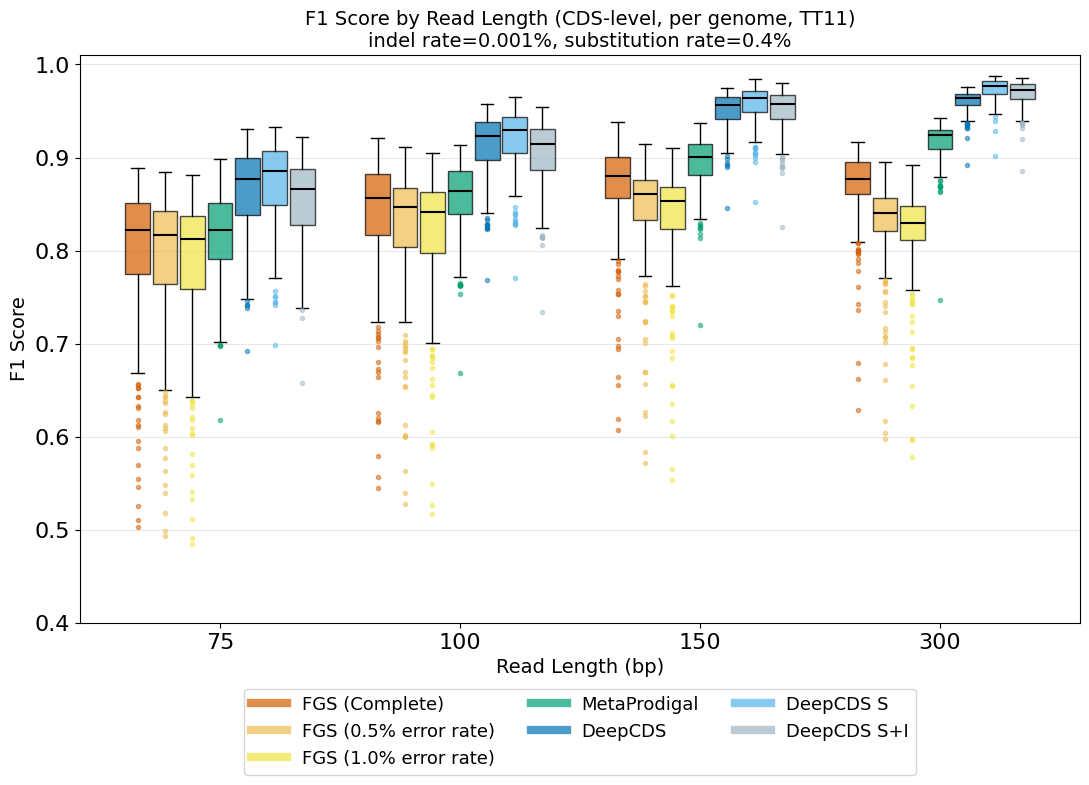

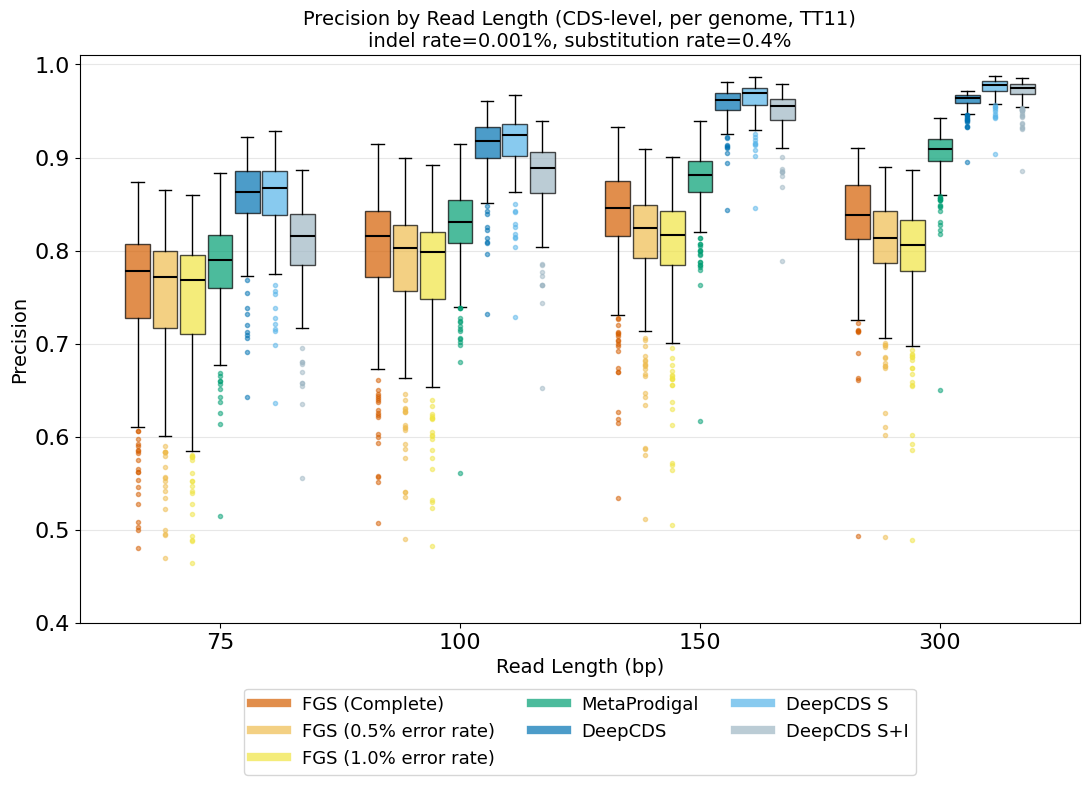

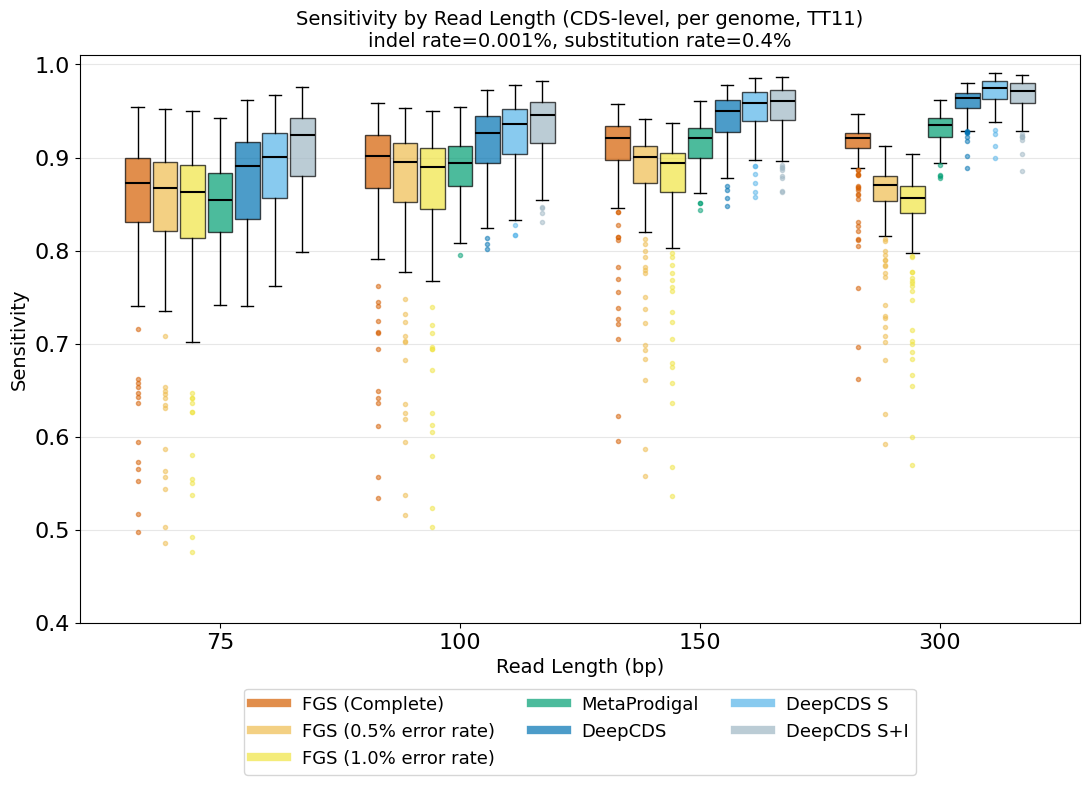

In [12]:
def plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, metric_name, ylabel):
    """Plot per-genome metric distributions as grouped boxplots across read lengths.

    All models are shown in a single figure. For each read length, one box per model
    is drawn side by side (mirroring the grouped bar chart layout). Models with no
    data at any read length are skipped.

    Args:
        per_genome_metrics_list: Dict of {length: {model: {metric_name: [values_per_genome]}}}.
        read_lengths: List of read lengths for the x-axis.
        metric_name: Key into metrics (e.g. 'f1_score', 'precision', 'recall').
        ylabel: Y-axis label and part of the plot title.
    """
    active_models = [m for m in model_names
                     if any(per_genome_metrics_list[l][m][metric_name] for l in read_lengths)]
    if not active_models:
        print("No data available.")
        return

    n_active = len(active_models)
    fig, ax = plt.subplots(figsize=(11, 8))

    x_positions = np.arange(len(read_lengths))
    box_width = 0.8 / n_active
    offsets = (np.arange(n_active) - (n_active - 1) / 2) * box_width

    for k, model in enumerate(active_models):
        color = model_colors[model]
        positions, data = [], []
        for i, length in enumerate(read_lengths):
            vals = per_genome_metrics_list[length][model][metric_name]
            if vals:
                positions.append(x_positions[i] + offsets[k])
                data.append(vals)
        if not data:
            continue

        bp = ax.boxplot(
            data,
            patch_artist=True,
            positions=positions,
            widths=box_width * 0.9,
            showfliers=True,
            flierprops=dict(marker='o', markersize=3, alpha=0.5,
                            markerfacecolor=color, markeredgecolor=color),
            manage_ticks=False,
        )
        for patch in bp['boxes']:
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        for line in bp['medians']:
            line.set_color('black')
            line.set_linewidth(1.5)
        ax.plot([], [], color=color, linewidth=6, alpha=0.7,
                label=model_display_names[model])
        

    ax.set_xlabel('Read Length (bp)', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(f'{ylabel} by Read Length (CDS-level, per genome, TT11)\n{error_rate_label}', fontsize = 14)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([str(l) for l in read_lengths])
    ax.set_ylim(0.4, 1.01)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=3) #-0.1 for merged plot; -0.07 for 30bp cutoff plot

    plt.tight_layout()
    #plt.savefig(f"cds_prediction_metrics_by_read_length_boxplot_{metric_name}.svg", dpi=500)
    #plt.savefig(f"cds_prediction_metrics_by_read_length_boxplot_{metric_name}.svg", dpi=500)
    plt.show()

plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'f1_score', 'F1 Score')
plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'precision', 'Precision')
plot_metric_by_read_length_boxplot(per_genome_metrics_list, read_lengths, 'recall', 'Sensitivity')

In [11]:
# Generate LaTeX table with 3 metric sections (F1, Sensitivity, Precision)
# Rows: model names grouped by metric; Columns: read lengths
# Best score per read length is bolded

metrics_order = [
    ('f1_score', 'F1 Score'),
    ('recall', 'Sensitivity'),
    ('precision', 'Precision'),
]

col_fmt = 'l' + 'c' * len(read_lengths)
header_cols = ' & '.join([f'{l}bp' for l in read_lengths])

lines = []
lines.append(r'\begin{table}[ht]')
lines.append(r'\centering')
lines.append(rf'\begin{{tabular}}{{{col_fmt}}}')
lines.append(r'\toprule')
lines.append(f' & {header_cols} \\')

for sec_idx, (metric_key, metric_label) in enumerate(metrics_order):
    lines.append(r'\midrule')
    lines.append(rf'\multicolumn{{{1 + len(read_lengths)}}}{{l}}{{\textbf{{{metric_label}}}}} \\')
    lines.append(r'\midrule')
    
    # Find best value per read length for this metric
    best_per_length = []
    for i in range(len(read_lengths)):
        col_vals = [aggregated_metrics[model][metric_key][i] for model in model_names]
        valid = [v for v in col_vals if not np.isnan(v)]
        best_per_length.append(max(valid) if valid else None)
    
    for model in model_names:
        display = model_display_names[model]
        vals = []
        for i, length in enumerate(read_lengths):
            v = aggregated_metrics[model][metric_key][i]
            if np.isnan(v):
                vals.append('--')
            elif best_per_length[i] is not None and v == best_per_length[i]:
                vals.append(rf'\textbf{{{v:.3f}}}')
            else:
                vals.append(f'{v:.3f}')
        row = f'{display} & ' + ' & '.join(vals) + r' \\'
        lines.append(row)

lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')
lines.append(r'\caption{TODO: WRITE CAPTION.}')
lines.append(r'\label{tab:cds_read_length_with_errors}')
lines.append(r'\end{table}')

latex_table = '\n'.join(lines)
print(latex_table)

\begin{table}[ht]
\centering
\begin{tabular}{lcccc}
\toprule
 & 75bp & 100bp & 150bp & 300bp \
\midrule
\multicolumn{5}{l}{\textbf{F1 Score}} \\
\midrule
FGS (Complete) & 0.814 & 0.849 & 0.875 & 0.874 \\
FGS (0.5% error rate) & 0.807 & 0.836 & 0.852 & 0.833 \\
FGS (1.0% error rate) & 0.802 & 0.830 & 0.844 & 0.823 \\
MetaProdigal & 0.818 & 0.858 & 0.895 & 0.918 \\
DeepCDS & 0.874 & 0.919 & 0.953 & 0.962 \\
DeepCDS S & \textbf{0.880} & \textbf{0.925} & \textbf{0.960} & \textbf{0.975} \\
DeepCDS S+I & 0.862 & 0.912 & 0.954 & 0.971 \\
\midrule
\multicolumn{5}{l}{\textbf{Sensitivity}} \\
\midrule
FGS (Complete) & 0.866 & 0.895 & 0.914 & 0.916 \\
FGS (0.5% error rate) & 0.860 & 0.885 & 0.891 & 0.861 \\
FGS (1.0% error rate) & 0.855 & 0.879 & 0.883 & 0.849 \\
MetaProdigal & 0.858 & 0.894 & 0.917 & 0.933 \\
DeepCDS & 0.887 & 0.923 & 0.947 & 0.962 \\
DeepCDS S & 0.898 & 0.930 & 0.955 & \textbf{0.974} \\
DeepCDS S+I & \textbf{0.919} & \textbf{0.940} & \textbf{0.956} & 0.969 \\
\midrule
\multicol